In [9]:
import requests, zipfile, io
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Chargement depuis UCI ML Repository (archive officielle)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00331/sentiment%20labelled%20sentences.zip"
r = requests.get(url, timeout=30)
z = zipfile.ZipFile(io.BytesIO(r.content))

# Extraction des avis Amazon
with z.open('sentiment labelled sentences/amazon_cells_labelled.txt') as f:
    df = pd.read_csv(f, sep='\t', header=None, names=['avis', 'sentiment'])

print(f"Forme : {df.shape}")
print(f"Distribution : {df['sentiment'].value_counts().to_dict()}")
print(f"\nExemples :")
print(df.sample(3, random_state=42))

# Feature engineering NLP : TF-IDF (unigrammes + bigrammes)
vectorizer = TfidfVectorizer(max_features=500, stop_words='english', ngram_range=(1, 2))
X = vectorizer.fit_transform(df['avis'])  # Sparse matrix
y = df['sentiment']
feature_names = list(vectorizer.get_feature_names_out())

print(f"\nVocabulaire TF-IDF : {len(feature_names)} tokens")

# Split stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF est déjà normalisé — pas de StandardScaler
X_train_sc = X_train
X_test_sc  = X_test

print(f"Train : {X_train.shape[0]} | Test : {X_test.shape[0]}")

Forme : (1000, 2)
Distribution : {0: 500, 1: 500}

Exemples :
                                                  avis  sentiment
521  Thanks again to Amazon for having the things I...          1
737  The tracfonewebsite is user friendly and makes...          1
740             I would highly recommend this product.          1

Vocabulaire TF-IDF : 500 tokens
Train : 800 | Test : 200


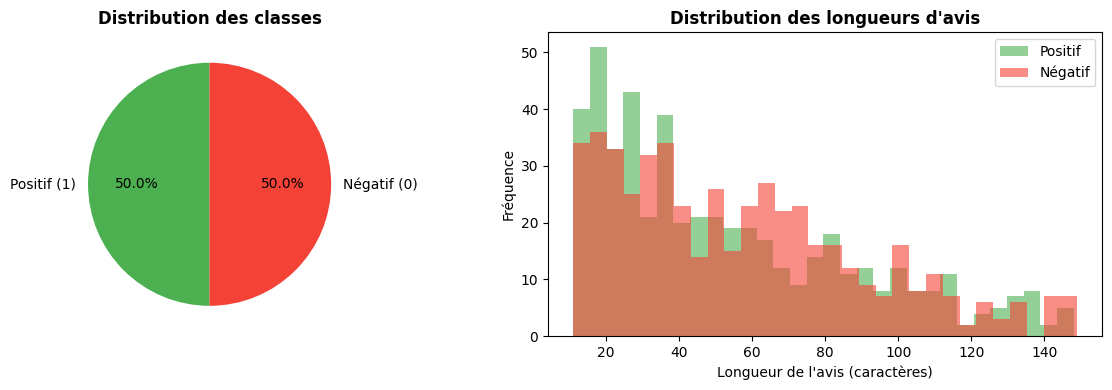

Longueur moyenne des avis positifs : 54 caractères
Longueur moyenne des avis négatifs : 57 caractères


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution des classes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
counts = df['sentiment'].value_counts()
axes[0].pie(counts, labels=['Positif (1)', 'Négatif (0)'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'], startangle=90)
axes[0].set_title('Distribution des classes', fontweight='bold')

# Longueur des avis
df['longueur'] = df['avis'].apply(len)
axes[1].hist(df[df['sentiment']==1]['longueur'], bins=30, alpha=0.6,
             color='#4CAF50', label='Positif')
axes[1].hist(df[df['sentiment']==0]['longueur'], bins=30, alpha=0.6,
             color='#F44336', label='Négatif')
axes[1].set_xlabel('Longueur de l\'avis (caractères)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des longueurs d\'avis', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('exploration_data.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Longueur moyenne des avis positifs : {df[df['sentiment']==1]['longueur'].mean():.0f} caractères")
print(f"Longueur moyenne des avis négatifs : {df[df['sentiment']==0]['longueur'].mean():.0f} caractères")

Logistic Regression    → Accuracy : 76.5% | F1-macro : 0.765 | F1-weighted : 0.765
Random Forest          → Accuracy : 75.5% | F1-macro : 0.755 | F1-weighted : 0.755
XGBoost                → Accuracy : 69.5% | F1-macro : 0.695 | F1-weighted : 0.695

=== TABLEAU COMPARATIF ===
                     accuracy  f1_macro  f1_weighted
Logistic Regression     0.765     0.765        0.765
Random Forest           0.755     0.755        0.755
XGBoost                 0.695     0.695        0.695


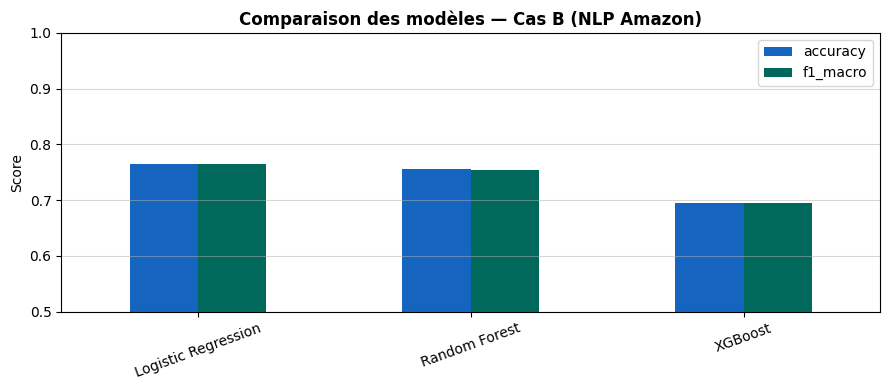

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

# Les trois modèles imposés par le TP
modeles = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost":             XGBClassifier(
                               n_estimators=100, random_state=42,
                               eval_metric='logloss', verbosity=0
                           ),
}

resultats = {}
for nom, modele in modeles.items():
    modele.fit(X_train_sc, y_train)
    pred    = modele.predict(X_test_sc)
    acc     = accuracy_score(y_test, pred)
    f1_mac  = f1_score(y_test, pred, average='macro')
    f1_wei  = f1_score(y_test, pred, average='weighted')
    resultats[nom] = {'accuracy': acc, 'f1_macro': f1_mac, 'f1_weighted': f1_wei}
    print(f"{nom:22s} → Accuracy : {acc*100:.1f}% | F1-macro : {f1_mac:.3f} | F1-weighted : {f1_wei:.3f}")

# Tableau comparatif
df_resultats = pd.DataFrame(resultats).T
print("\n=== TABLEAU COMPARATIF ===")
print(df_resultats.round(3))

# Visualisation
df_resultats[['accuracy', 'f1_macro']].plot(kind='bar', figsize=(9, 4),
    color=['#1565C0', '#00695C'])
plt.title('Comparaison des modèles — Cas B (NLP Amazon)', fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.ylim(0.5, 1.0)
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.savefig('comparaison_modeles.png', dpi=150)
plt.show()

=== RAPPORT DÉTAILLÉ — Logistic Regression ===
              precision    recall  f1-score   support

 Négatif (0)       0.75      0.79      0.77       100
 Positif (1)       0.78      0.74      0.76       100

    accuracy                           0.77       200
   macro avg       0.77      0.77      0.76       200
weighted avg       0.77      0.77      0.76       200



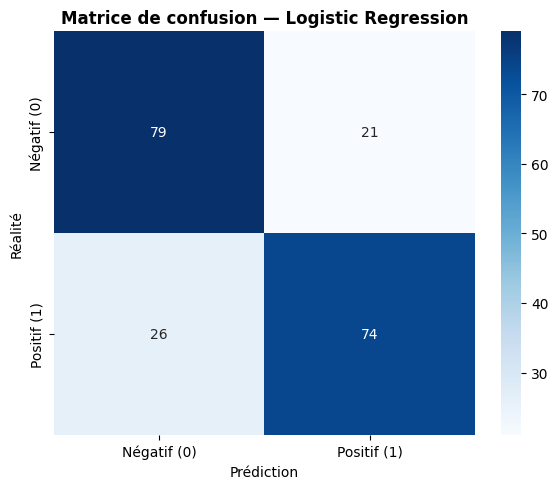


=== DÉCOMPOSITION DES ERREURS ===
Vrais Positifs  (TP) : 74  → Avis positifs correctement détectés
Vrais Négatifs  (TN) : 79  → Avis négatifs correctement détectés
Faux Positifs   (FP) : 21  → Avis négatifs classés positifs
Faux Négatifs   (FN) : 26  → Avis positifs classés négatifs


In [12]:
from sklearn.metrics import confusion_matrix, classification_report

# Meilleur modèle : Logistic Regression
NOM_MEILLEUR = "Logistic Regression"
meilleur = modeles[NOM_MEILLEUR]
y_pred   = meilleur.predict(X_test_sc)

# Rapport complet
print(f"=== RAPPORT DÉTAILLÉ — {NOM_MEILLEUR} ===")
print(classification_report(y_test, y_pred,
      target_names=['Négatif (0)', 'Positif (1)']))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Négatif (0)', 'Positif (1)'],
            yticklabels=['Négatif (0)', 'Positif (1)'])
plt.title(f'Matrice de confusion — {NOM_MEILLEUR}', fontweight='bold')
plt.ylabel('Réalité')
plt.xlabel('Prédiction')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Décomposition des erreurs
tn, fp, fn, tp = cm.ravel()
print(f"\n=== DÉCOMPOSITION DES ERREURS ===")
print(f"Vrais Positifs  (TP) : {tp}  → Avis positifs correctement détectés")
print(f"Vrais Négatifs  (TN) : {tn}  → Avis négatifs correctement détectés")
print(f"Faux Positifs   (FP) : {fp}  → Avis négatifs classés positifs")
print(f"Faux Négatifs   (FN) : {fn}  → Avis positifs classés négatifs")

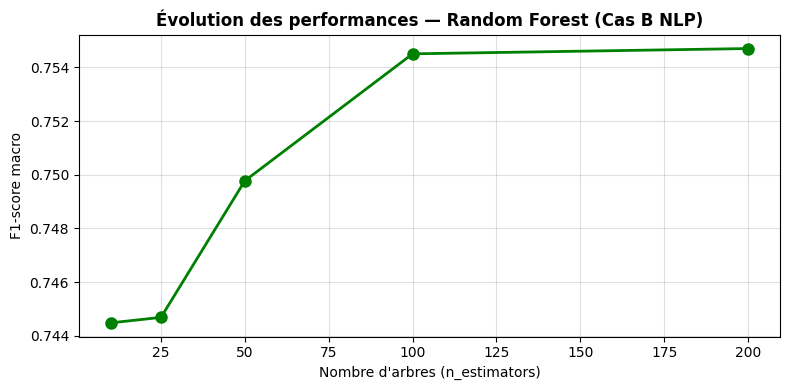


Score LR (référence) : 0.765
Meilleur RF          : 0.755 (n_estimators=200)


In [13]:
# Évolution de Random Forest selon le nombre d'arbres
n_estimators_range = [10, 25, 50, 100, 200]
scores_rf = []
for n in n_estimators_range:
    rf_temp = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_temp.fit(X_train_sc, y_train)
    pred_temp = rf_temp.predict(X_test_sc)
    scores_rf.append(f1_score(y_test, pred_temp, average='macro'))

plt.figure(figsize=(8, 4))
plt.plot(n_estimators_range, scores_rf, 'g-o', linewidth=2, markersize=8)
plt.xlabel("Nombre d'arbres (n_estimators)")
plt.ylabel("F1-score macro")
plt.title("Évolution des performances — Random Forest (Cas B NLP)", fontweight='bold')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('rf_evolution.png', dpi=150)
plt.show()

print(f"\nScore LR (référence) : {resultats['Logistic Regression']['f1_macro']:.3f}")
print(f"Meilleur RF          : {max(scores_rf):.3f} (n_estimators={n_estimators_range[scores_rf.index(max(scores_rf))]})"
)

In [14]:
# Analyser les erreurs : quels avis sont mal classés ?
X_test_dense = X_test_sc.toarray()
y_test_arr   = y_test.values
test_indices = y_test.index

# Récupérer les avis originaux du test set
df_test = df.loc[test_indices].copy()
df_test['prediction'] = y_pred
df_test['correct']    = df_test['sentiment'] == df_test['prediction']

print("=== EXEMPLES DE FAUX NÉGATIFS (avis négatifs classés positifs) ===")
fn_examples = df_test[(df_test['sentiment']==0) & (df_test['prediction']==1)]
for _, row in fn_examples.head(3).iterrows():
    print(f"  → '{row['avis']}'")

print("\n=== EXEMPLES DE FAUX POSITIFS (avis positifs classés négatifs) ===")
fp_examples = df_test[(df_test['sentiment']==1) & (df_test['prediction']==0)]
for _, row in fp_examples.head(3).iterrows():
    print(f"  → '{row['avis']}'")

=== EXEMPLES DE FAUX NÉGATIFS (avis négatifs classés positifs) ===
  → 'i got this phone around the end of may and i'm completely unhappy with it.'
  → 'I've had this bluetoooth headset for some time now and still not comfortable with the way it fits on the ear.'
  → 'Not nearly as good looking as the AMAZON picture makes it look.'

=== EXEMPLES DE FAUX POSITIFS (avis positifs classés négatifs) ===
  → 'Five star Plus, plus.'
  → 'Because both ears are occupied, background is not distracting at all.'
  → 'Arrived quickly and much less expensive than others being sold.'


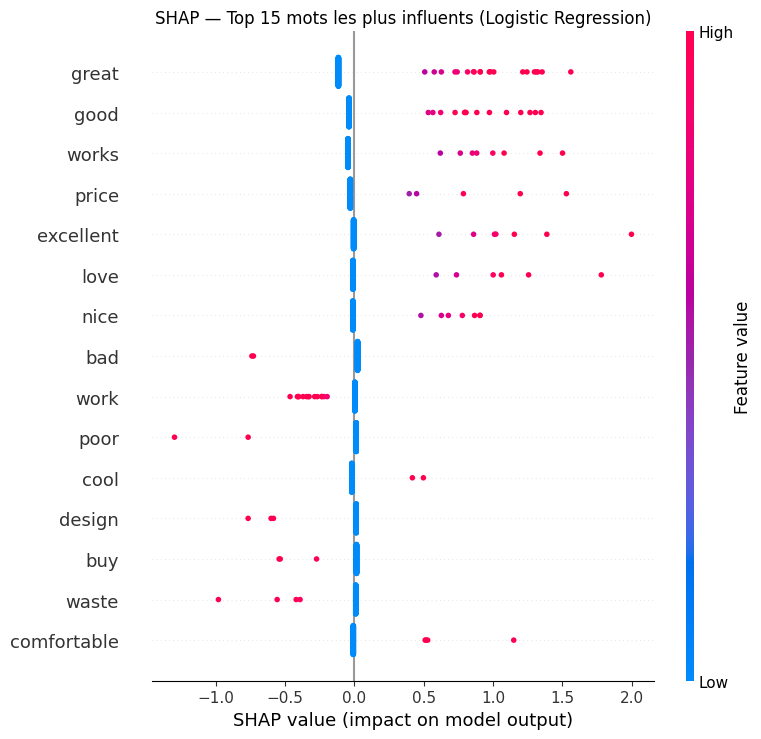


=== TOP 10 MOTS PAR IMPORTANCE SHAP ===
   1. great                     | SHAP moyen : 0.2025 | NEG →
   2. good                      | SHAP moyen : 0.1005 | POS →
   3. works                     | SHAP moyen : 0.0839 | NEG →
   4. price                     | SHAP moyen : 0.0506 | NEG →
   5. excellent                 | SHAP moyen : 0.0452 | POS →
   6. love                      | SHAP moyen : 0.0419 | POS →
   7. nice                      | SHAP moyen : 0.0366 | POS →
   8. bad                       | SHAP moyen : 0.0302 | POS →
   9. work                      | SHAP moyen : 0.0260 | NEG →
  10. poor                      | SHAP moyen : 0.0234 | POS →


In [15]:
import shap
import scipy.sparse as sp
import numpy as np
import matplotlib.pyplot as plt

# ════════════════════════════════════════════════════════════════════
# SHAP avec LinearExplainer sur Logistic Regression
# Beaucoup plus rapide que TreeExplainer sur données TF-IDF sparse
# ════════════════════════════════════════════════════════════════════

lr_model = modeles["Logistic Regression"]

# Garder le format sparse — LinearExplainer le gère nativement
X_sample = X_test_sc[:200]  # 200 exemples suffisent

explainer   = shap.LinearExplainer(lr_model, X_train_sc)
shap_values = explainer.shap_values(X_sample)

# LinearExplainer retourne toujours un tableau 2D (n_samples, n_features)
sv = shap_values

# ── Summary plot : top 15 mots ───────────────────────────────────────
X_sample_dense = X_sample.toarray() if sp.issparse(X_sample) else X_sample

plt.figure()
shap.summary_plot(
    sv, X_sample_dense,
    feature_names=feature_names,
    max_display=15,
    show=False
)
plt.title("SHAP — Top 15 mots les plus influents (Logistic Regression)")
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Top 10 mots par importance SHAP absolue ───────────────────────────
mean_shap = np.abs(sv).mean(axis=0)
top_idx   = np.argsort(mean_shap)[::-1][:10]
print("\n=== TOP 10 MOTS PAR IMPORTANCE SHAP ===")
for rank, idx in enumerate(top_idx, 1):
    direction = 'POS →' if sv[:, idx].mean() > 0 else 'NEG →'
    print(f"  {rank:2d}. {feature_names[idx]:25s} | SHAP moyen : {mean_shap[idx]:.4f} | {direction}")

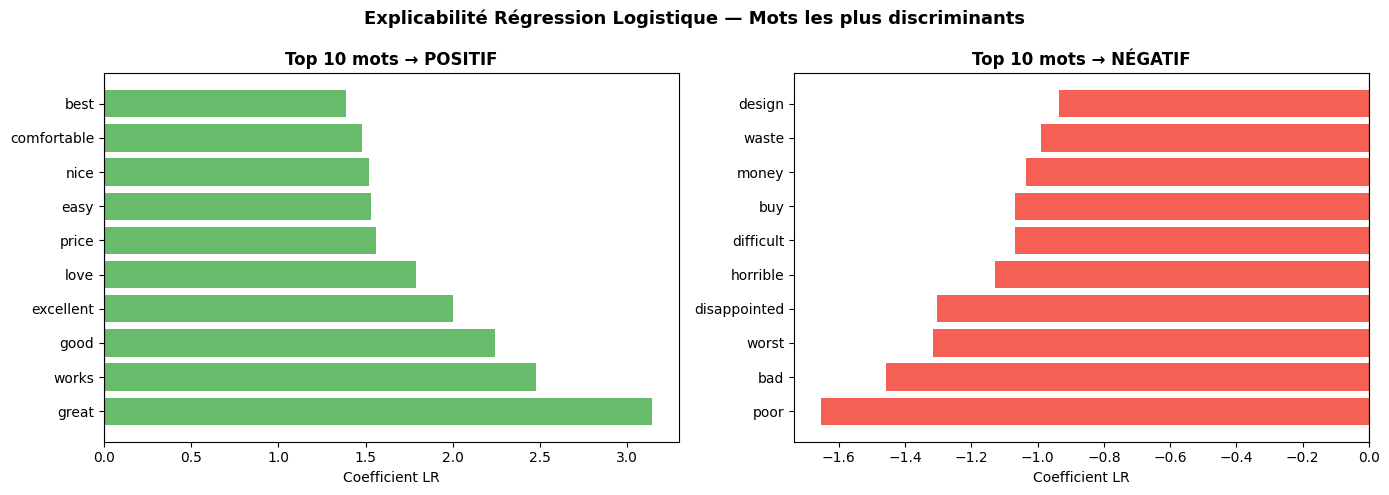

In [16]:
# Bonus : coefficients de la Régression Logistique (explicabilité native)
lr_model  = modeles["Logistic Regression"]
coefs     = lr_model.coef_[0]
feat_df   = pd.DataFrame({'mot': feature_names, 'coef': coefs})

top_pos = feat_df.nlargest(10, 'coef')
top_neg = feat_df.nsmallest(10, 'coef')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.barh(top_pos['mot'], top_pos['coef'], color='#4CAF50', alpha=0.85)
ax1.set_title('Top 10 mots → POSITIF', fontweight='bold')
ax1.set_xlabel('Coefficient LR')
ax1.axvline(0, color='black', linewidth=0.8)

ax2.barh(top_neg['mot'], top_neg['coef'], color='#F44336', alpha=0.85)
ax2.set_title('Top 10 mots → NÉGATIF', fontweight='bold')
ax2.set_xlabel('Coefficient LR')
ax2.axvline(0, color='black', linewidth=0.8)

plt.suptitle('Explicabilité Régression Logistique — Mots les plus discriminants',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()